In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [2]:
#load and show a few lines of the dataset
full_df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')
full_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
full_df.shape
#here we got the number of rows and columns in 
#the dataset

(284807, 31)

In [4]:
#now our target column is class, 0 -not fraud,
#1-fraud
full_df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
#in percentages
full_df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [6]:
fraud_count = full_df['Class'].value_counts()
print("Non-Fraud:", fraud_count[0])
print("Fraud:", fraud_count[1])

Non-Fraud: 284315
Fraud: 492


In [7]:
#now we check for missing values
full_df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Everything above is showing zero because there is no missing values, but we used sum, so.....

In [8]:
full_df.isnull().values.any()

np.False_

Since it says false, theere are no missing values

In [9]:
full_df.duplicated().sum()

np.int64(1081)

We have a lot of duplicates here
we need to drop'em...

In [10]:
full_df = full_df.drop_duplicates()

In [11]:
full_df.duplicated().sum()

np.int64(0)

Checked if all the duplicates have been dropped or not

In [12]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

In [13]:
full_df.describe
#this will give descriptions

<bound method NDFrame.describe of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599

In [14]:
full_df.groupby('Class')['Amount'].describe()
#this gives us info divided by class

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


In [15]:
#We need to compare mean Amount
full_df.groupby('Class')['Amount'].mean()

Class
0     88.413575
1    123.871860
Name: Amount, dtype: float64

In [16]:
#but usually the data has skewed distribution, so we need
#to use use median, it is more reliable
full_df.groupby('Class')['Amount'].median()

Class
0    22.00
1     9.82
Name: Amount, dtype: float64

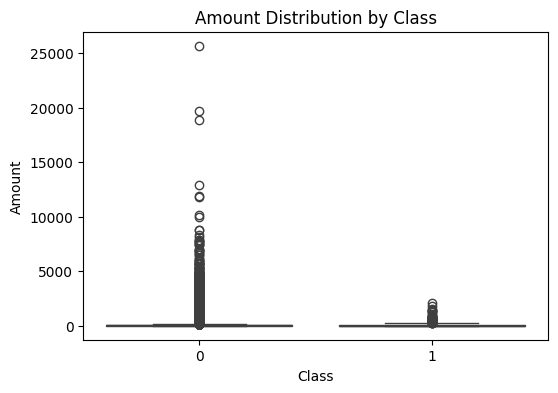

In [17]:
#next we need an graph, for visual comparision
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y='Amount', data=full_df)
plt.title("Amount Distribution by Class")
plt.show()

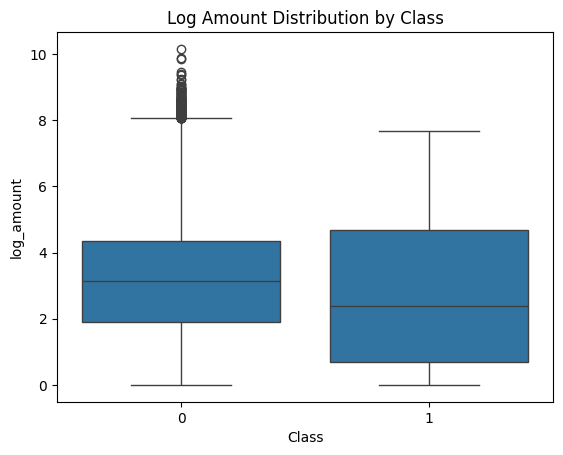

In [18]:
#got his from reddit
#use log scale since amount is highly
#skewed
import numpy as np

full_df['log_amount'] = np.log1p(full_df['Amount'])

sns.boxplot(x='Class', y='log_amount', data=full_df)
plt.title("Log Amount Distribution by Class")
plt.show()

In [19]:
#the fraud class(1) median line is slightly lower
#than then non-fraud one, the class 0
#so this means, fraud transactions have a lower average
#amount compared to non-fraud transactions

#the median is different fraud transactions show
#a lower median amount.

#Non-Fraud shows many high-value outliers above 8
#Fraud has fewer extreme high outliers, seen in the previous 
#graph
#extreme outliers are present, especially in the non fraud class.

#Transaction amount distribution is positively skewed, meaning 
#most transactions are of lower value, while a small number 
#of high-value transactions create a long right tail. 
#Log transformation was applied to reduce skewness and 
#improve interpretability, though some upper-tail spread 
#remains visible.
#We interpreted the right tail from the boxplot by observing that:
#The upper whisker is longer than the lower whisker.
#There are many extreme outliers on the higher value side.
#The lower side is comparatively compressed.
#This indicates that high transaction values stretch 
#the distribution toward larger numbers, forming a long right tail.


In [20]:
#now we need to do time-based eda
#in the dataset, time represents seconds elapsed
#between each transacation and the first transaction

full_df['Time'].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

In [21]:
#So the data set covers two days of transactions
full_df['Hour'] = full_df['Time'] / 3600
full_df['Hour'] = full_df['Hour'] % 24   #converts into 0–24 hour format

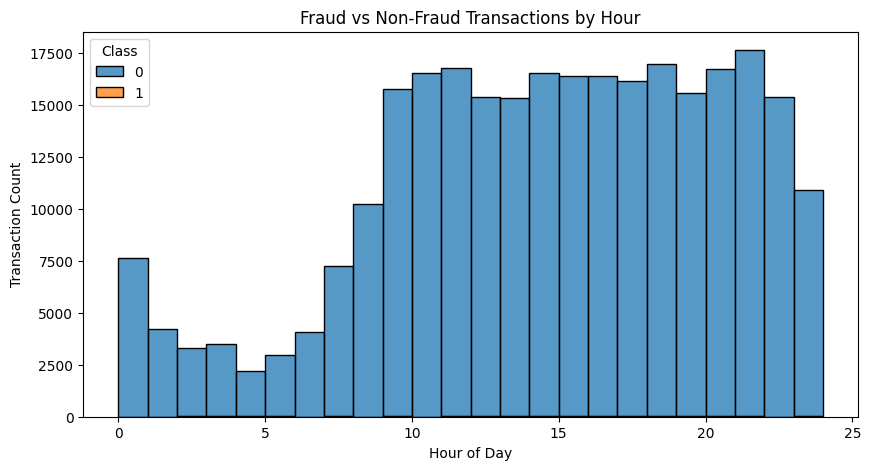

In [22]:
#now we need to plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(data=full_df, x='Hour', hue='Class', bins=24, multiple='stack')
plt.title("Fraud vs Non-Fraud Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Count")
plt.show()

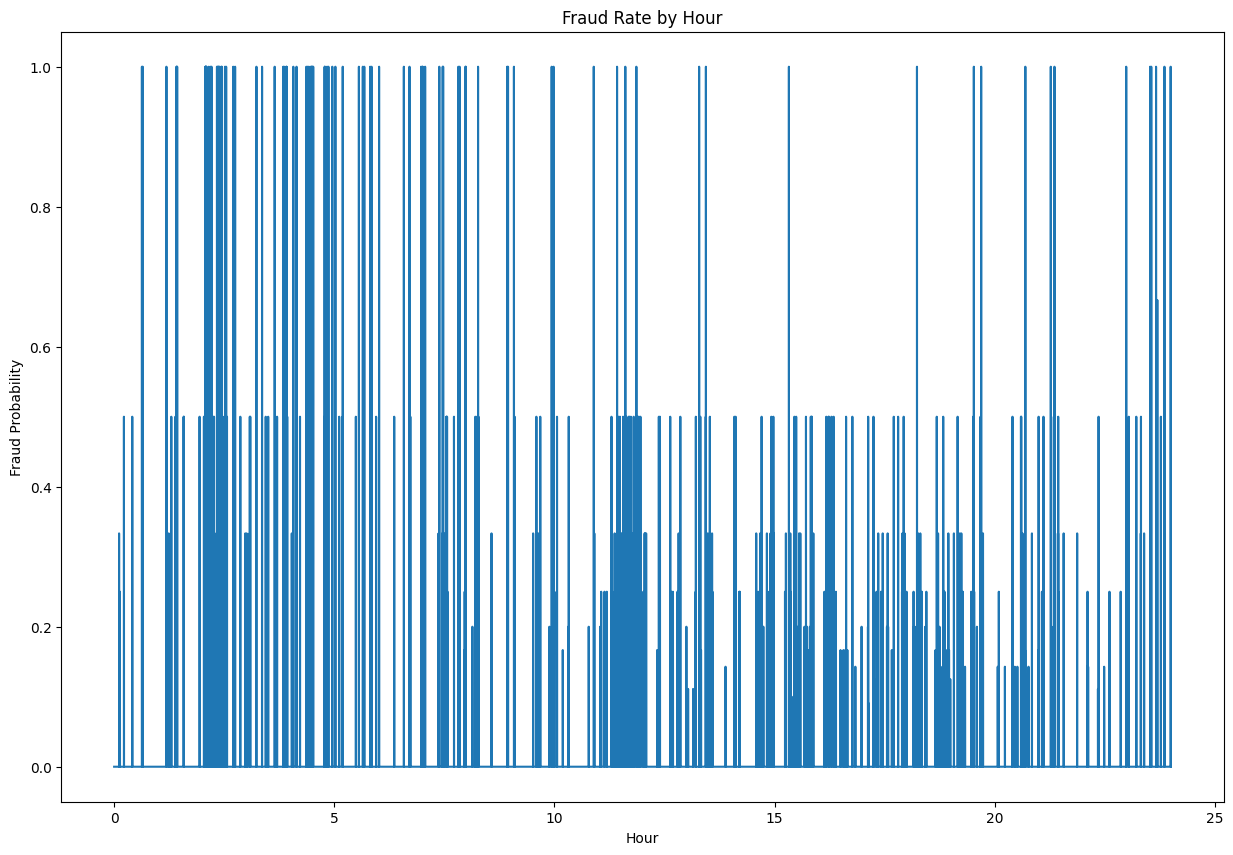

In [23]:
#we need to compare fraud rate per hour
fraud_by_hour = full_df.groupby('Hour')['Class'].mean()

plt.figure(figsize=(15,10))
fraud_by_hour.plot()
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Probability")
plt.show()

In [24]:
#Nowe we will do correctional analysis, it helps us
#understand which features are strongly related to fraud
#which feature might be important for ML model

corr_matrix = full_df.corr()

In [25]:
corr_with_class = corr_matrix['Class'].sort_values(ascending=False)
print(corr_with_class)

Class         1.000000
V11           0.149067
V4            0.129326
V2            0.084624
V19           0.033631
V8            0.033068
V21           0.026357
V27           0.021892
V20           0.021486
V28           0.009682
Amount        0.005777
V22           0.004887
V26           0.004265
V25           0.003202
V15          -0.003300
V13          -0.003897
V23          -0.006333
V24          -0.007210
log_amount   -0.007798
Time         -0.012359
Hour         -0.016696
V6           -0.043915
V5           -0.087812
V9           -0.094021
V1           -0.094486
V18          -0.105340
V7           -0.172347
V3           -0.182322
V16          -0.187186
V10          -0.206971
V12          -0.250711
V14          -0.293375
V17          -0.313498
Name: Class, dtype: float64


This will show:
Features positively correlated with fraud
Features negatively correlated with fraud
Look for values like:
Above +0.2
Below −0.2
Those are relatively strong signals in this dataset.

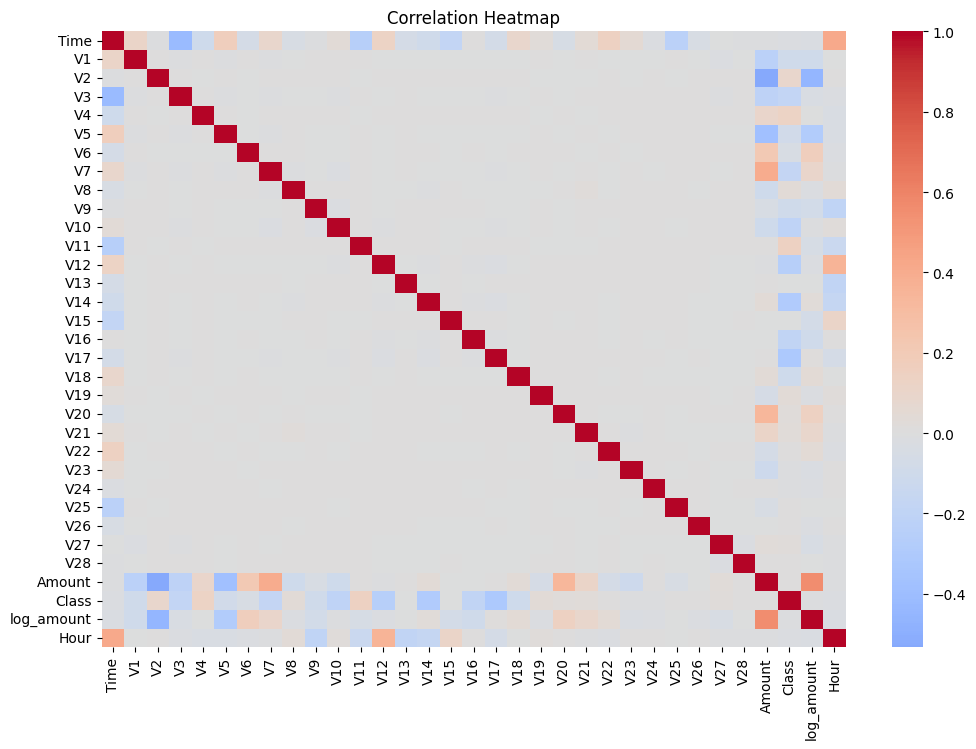

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(full_df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

This one is too hard and crowded to read, so.....

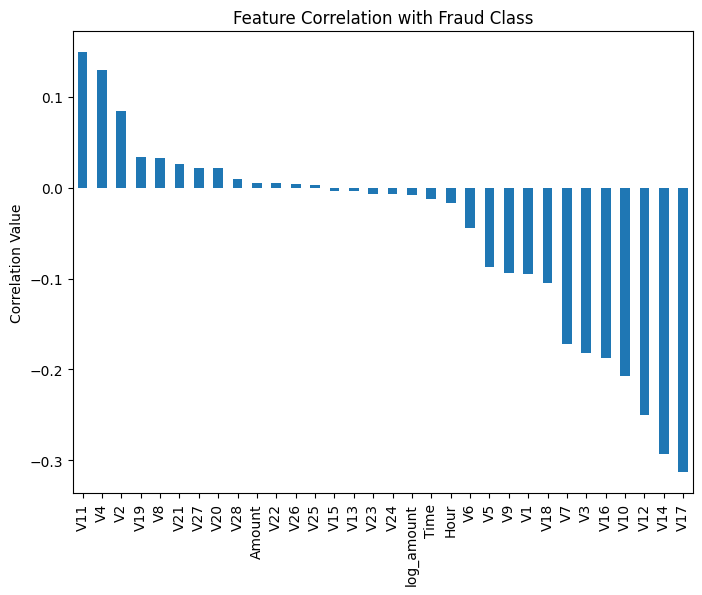

In [27]:
plt.figure(figsize=(8,6))
corr_with_class.drop('Class').plot(kind='bar')
plt.title("Feature Correlation with Fraud Class")
plt.ylabel("Correlation Value")
plt.show()